In [1]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected+png'
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_white"

instagram_data = pd.read_csv('Instagram-Data.csv')

instagram_data.head()

,Post ID,Description,Duration (secs),Publish time,Permalink,Post type,Data comment,Date,Impressions,Reach,Likes,Shares,Follows,Comments,Saves,Plays
0,1.799668e+16,Building end-to-end projects will help you lea...,0,01/02/2024 20:19,https://www.instagram.com/p/C1n9wjkLL71/,IG carousel,NaN,Lifetime,20149,16693,741,131,22.0,6,890,NaN
1,1.800604e+16,Data Engineers are crucial in ensuring that da...,0,01/01/2024 20:26,https://www.instagram.com/p/C1lZvITLD3O/,IG carousel,NaN,Lifetime,15666,13075,538,67,31.0,5,490,NaN
2,1.829417e+16,Here’s a list of 190+ Data Science projects ba...,0,03/29/2024 23:00,https://www.instagram.com/p/C5IKcAfLurI/,IG image,NaN,Lifetime,222022,170730,783,127,252.0,17,995,0.0
3,1.809139e+16,"During cricket leagues like IPL, we see a lot ...",0,03/29/2024 02:52,https://www.instagram.com/p/C5GAPksLLRy/,IG carousel,NaN,Lifetime,17930,15271,573,114,18.0,8,576,NaN
4,1.796449e+16,The tools used by a data scientist can vary si...,0,03/28/2024 02:50,https://www.instagram.com/p/C5DbPM8ry8P/,IG carousel,NaN,Lifetime,15530,12885,636,113,29.0,11,911,NaN


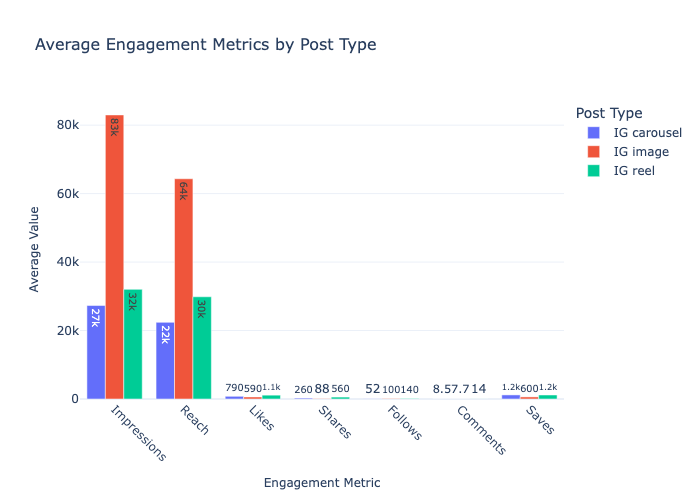

In [2]:
import plotly.express as px

# filter data for relevant metrics and post types
engagement_metrics = ['Impressions', 'Reach', 'Likes', 'Shares', 'Follows', 'Comments', 'Saves']
content_performance = instagram_data[['Post type'] + engagement_metrics]

# group by 'Post type' and calculate average engagement metrics
performance_summary = content_performance.groupby('Post type').mean().reset_index()

# melt the data for easier plotting
performance_melted = performance_summary.melt(id_vars=['Post type'], var_name='Metric', value_name='Average Value')

# plotting engagement metrics by post type
fig = px.bar(
    performance_melted,
    x='Metric',
    y='Average Value',
    color='Post type',
    barmode='group',
    title='Average Engagement Metrics by Post Type',
    labels={'Metric': 'Engagement Metric', 'Average Value': 'Average Value'},
    text_auto='.2s'
)

fig.update_layout(
    title_font_size=16,
    xaxis_title_font_size=12,
    yaxis_title_font_size=12,
    legend_title='Post Type',
    xaxis_tickangle=45
)

fig.show()

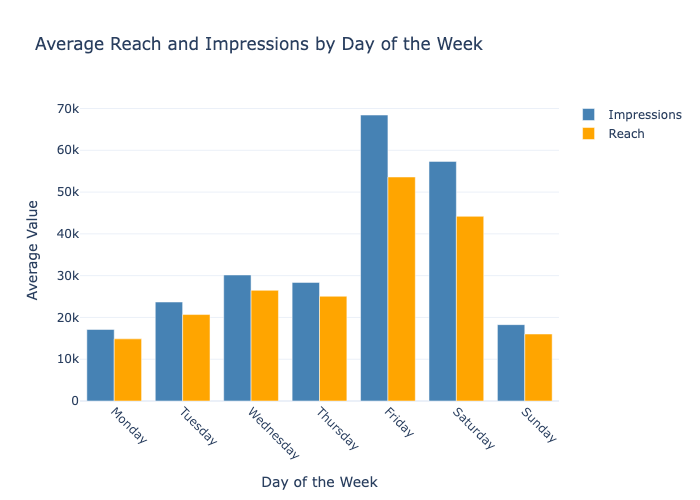

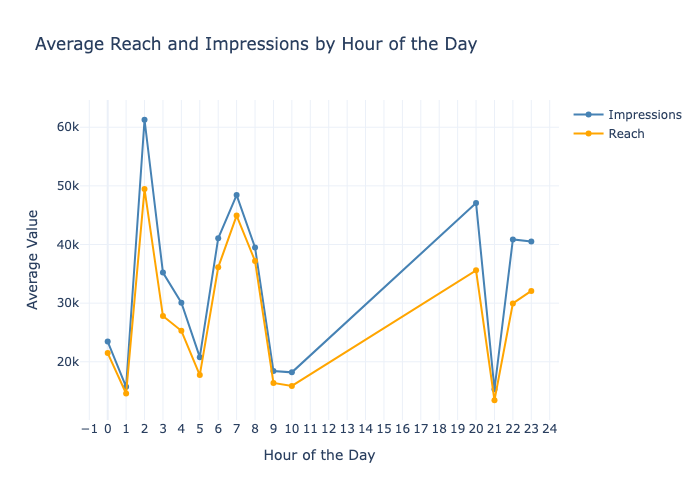

In [3]:
# extracting and converting publish time to datetime
instagram_data['Publish time'] = pd.to_datetime(instagram_data['Publish time'])

# creating additional time-based features
instagram_data['Day of Week'] = instagram_data['Publish time'].dt.day_name()
instagram_data['Hour of Day'] = instagram_data['Publish time'].dt.hour

# grouping data by day of the week and hour of the day for Reach and Impressions
time_analysis = instagram_data[['Day of Week', 'Hour of Day', 'Impressions', 'Reach']]

# aggregating metrics
day_of_week_summary = time_analysis.groupby('Day of Week')[['Impressions', 'Reach']].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
hour_of_day_summary = time_analysis.groupby('Hour of Day')[['Impressions', 'Reach']].mean()

# visualization: Day of the Week
fig_day = go.Figure()
fig_day.add_trace(go.Bar(
    x=day_of_week_summary.index,
    y=day_of_week_summary['Impressions'],
    name='Impressions',
    marker_color='steelblue'
))
fig_day.add_trace(go.Bar(
    x=day_of_week_summary.index,
    y=day_of_week_summary['Reach'],
    name='Reach',
    marker_color='orange'
))
fig_day.update_layout(
    title='Average Reach and Impressions by Day of the Week',
    xaxis_title='Day of the Week',
    yaxis_title='Average Value',
    barmode='group',
    xaxis_tickangle=45
)

fig_day.show()

# visualization: Hour of the Day
fig_hour = go.Figure()
fig_hour.add_trace(go.Scatter(
    x=hour_of_day_summary.index,
    y=hour_of_day_summary['Impressions'],
    mode='lines+markers',
    name='Impressions',
    line=dict(color='steelblue')
))
fig_hour.add_trace(go.Scatter(
    x=hour_of_day_summary.index,
    y=hour_of_day_summary['Reach'],
    mode='lines+markers',
    name='Reach',
    line=dict(color='orange')
))
fig_hour.update_layout(
    title='Average Reach and Impressions by Hour of the Day',
    xaxis_title='Hour of the Day',
    yaxis_title='Average Value',
    xaxis=dict(tickmode='linear', tick0=0, dtick=1)
)

fig_hour.show()

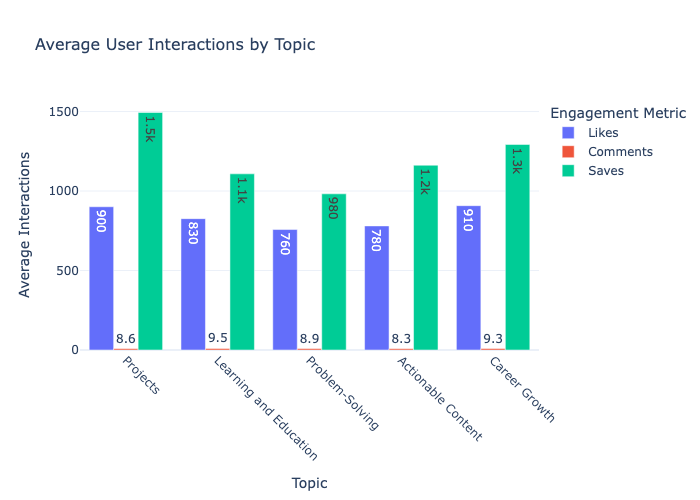

In [4]:
# clean the descriptions by removing hashtags
instagram_data['Cleaned Description'] = instagram_data['Description'].str.replace(r'#\S+', '', regex=True)
interaction_metrics = ['Likes', 'Comments', 'Saves']

# define topics and their associated keywords
topics = {
    "Projects": ["projects", "solved", "explained", "ideas"],
    "Learning and Education": ["learning", "science", "learn", "python", "analysis"],
    "Problem-Solving": ["problems", "using", "algorithms"],
    "Actionable Content": ["try", "use", "list", "let"],
    "Career Growth": ["link", "bio"],
}

# aggregate engagement metrics by topic
topic_engagement = {
    topic: instagram_data[
        instagram_data['Cleaned Description']
        .str.contains('|'.join(keywords), case=False, na=False)][interaction_metrics].mean()
    for topic, keywords in topics.items()
}

# convert to DataFrame
topic_engagement_df = pd.DataFrame(topic_engagement).T.reset_index()
topic_engagement_df.columns = ['Topic', 'Likes', 'Comments', 'Saves']

# melt DataFrame for Plotly
topic_engagement_melted = topic_engagement_df.melt(
    id_vars='Topic', var_name='Engagement Metric', value_name='Average Value'
)

fig = px.bar(
    topic_engagement_melted,
    x='Topic',
    y='Average Value',
    color='Engagement Metric',
    barmode='group',
    title='Average User Interactions by Topic',
    labels={'Average Value': 'Average Interactions'},
    text_auto='.2s',
)

fig.update_layout(
    title_font_size=16,
    xaxis_title='Topic',
    yaxis_title='Average Interactions',
    legend_title='Engagement Metric',
    xaxis_tickangle=45
)

fig.show()

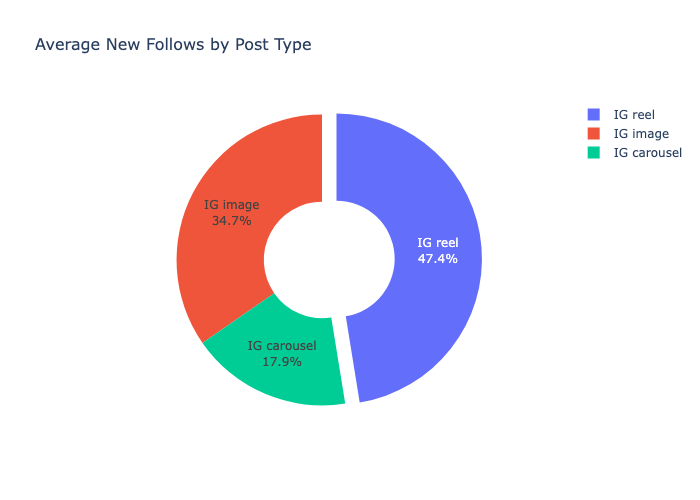

In [5]:
follows_by_post_type = instagram_data.groupby('Post type')['Follows'].mean().sort_values(ascending=False).reset_index()

# plotting follows by post type using a donut chart
fig = px.pie(
    follows_by_post_type,
    names='Post type',
    values='Follows',
    title='Average New Follows by Post Type',
    hole=0.4,
    labels={'Post type': 'Post Type', 'Follows': 'Average New Follows'},
)

fig.update_traces(
    textinfo='percent+label',  # display percentage and label on the chart
    pull=[0.1 if i == follows_by_post_type['Follows'].idxmax() else 0 for i in range(len(follows_by_post_type))]
)  # highlight the post type with the highest average follows

fig.update_layout(
    title_font_size=16,
)

fig.show()

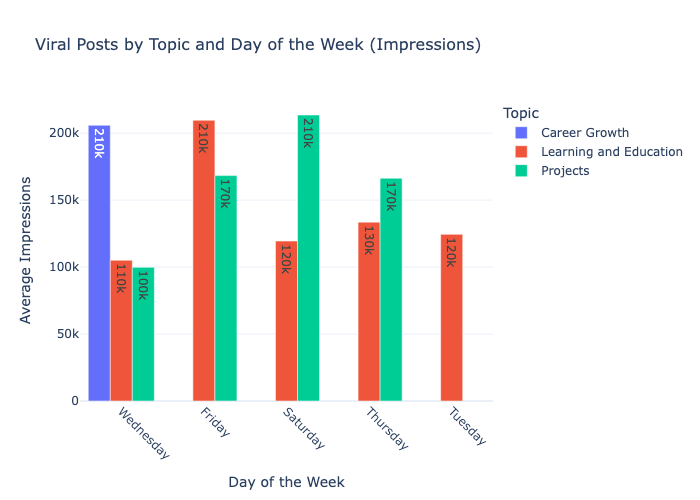

In [6]:
import plotly.express as px

# define "viral" posts as those with impressions in the top 10% of the dataset
viral_threshold = instagram_data['Impressions'].quantile(0.90)
viral_posts = instagram_data[instagram_data['Impressions'] >= viral_threshold].copy()

# assign topics based on keywords in descriptions
def assign_topic(desc):
    desc = desc.lower() if isinstance(desc, str) else ""
    if 'projects' in desc:
        return 'Projects'
    elif any(word in desc for word in ['learn', 'science', 'analysis', 'python']):
        return 'Learning and Education'
    elif any(word in desc for word in ['problems', 'using', 'algorithms']):
        return 'Problem-Solving'
    elif any(word in desc for word in ['list', 'try', 'let', 'use']):
        return 'Actionable Content'
    elif any(word in desc for word in ['bio', 'link']):
        return 'Career Growth'
    else:
        return 'Other'

viral_posts['Topic'] = viral_posts['Cleaned Description'].apply(assign_topic)

# aggregating viral posts by topic and day of the week
viral_topic_day = viral_posts.groupby(['Topic', 'Day of Week'])[['Impressions']].mean().reset_index()

# visualization: Viral posts by topic and day of the week
fig = px.bar(
    viral_topic_day,
    x='Day of Week',
    y='Impressions',
    color='Topic',
    barmode='group',
    title='Viral Posts by Topic and Day of the Week (Impressions)',
    labels={'Impressions': 'Average Impressions', 'Day of Week': 'Day of the Week'},
    text_auto='.2s'
)

fig.update_layout(
    title_font_size=16,
    xaxis_title='Day of the Week',
    yaxis_title='Average Impressions',
    legend_title='Topic',
    xaxis_tickangle=45
)

fig.show()

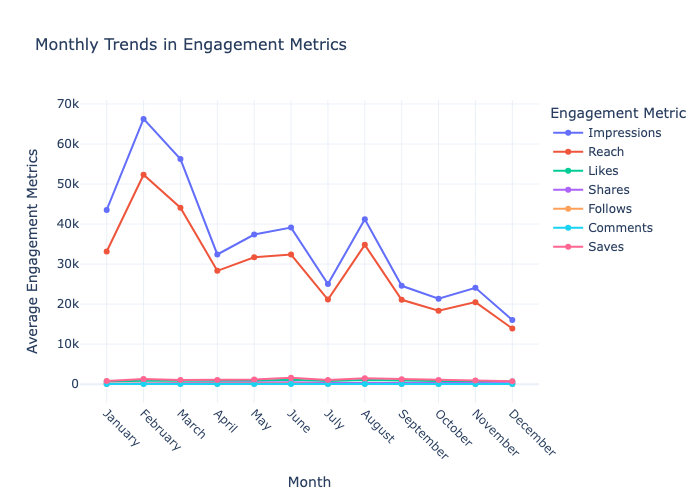

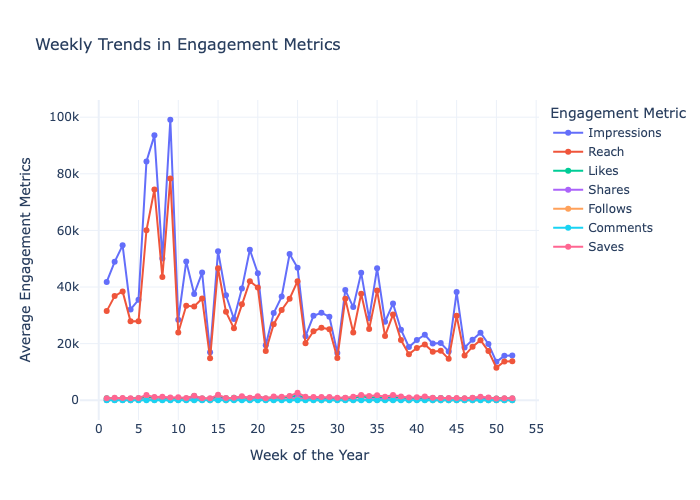

In [7]:
# extract month and week from the Publish time for seasonal trend analysis
instagram_data['Month'] = instagram_data['Publish time'].dt.month_name()
instagram_data['Week'] = instagram_data['Publish time'].dt.isocalendar().week

# group data by month and week to analyze trends in engagement metrics
monthly_engagement = instagram_data.groupby('Month')[engagement_metrics].mean().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
).reset_index()

weekly_engagement = instagram_data.groupby('Week')[engagement_metrics].mean().reset_index()

# visualization: Monthly engagement trends
fig_monthly = px.line(
    monthly_engagement.melt(id_vars='Month', var_name='Engagement Metric', value_name='Average Value'),
    x='Month',
    y='Average Value',
    color='Engagement Metric',
    markers=True,
    title='Monthly Trends in Engagement Metrics',
    labels={'Average Value': 'Average Engagement', 'Month': 'Month'}
)

fig_monthly.update_layout(
    title_font_size=16,
    xaxis_title='Month',
    yaxis_title='Average Engagement Metrics',
    xaxis_tickangle=45
)

# visualization: Weekly engagement trends
fig_weekly = px.line(
    weekly_engagement.melt(id_vars='Week', var_name='Engagement Metric', value_name='Average Value'),
    x='Week',
    y='Average Value',
    color='Engagement Metric',
    markers=True,
    title='Weekly Trends in Engagement Metrics',
    labels={'Average Value': 'Average Engagement', 'Week': 'Week of the Year'}
)

fig_weekly.update_layout(
    title_font_size=16,
    xaxis_title='Week of the Year',
    yaxis_title='Average Engagement Metrics',
    xaxis_tickmode='linear',
    xaxis_dtick=5
)

fig_monthly.show()
fig_weekly.show()

In [8]:
# group data by post type and calculate average engagement metrics
post_type_summary = instagram_data.groupby('Post type')[
    ['Follows', 'Likes', 'Comments', 'Shares', 'Saves', 'Impressions', 'Reach']
].mean()

# add day of the week and hour of the day to the dataset
day_time_summary = instagram_data.copy()
day_time_summary['Day of Week'] = day_time_summary['Publish time'].dt.day_name()
day_time_summary['Hour of Day'] = day_time_summary['Publish time'].dt.hour

# group data by day of the week and post type to calculate daily engagement metrics
daily_post_type_summary = day_time_summary.groupby(['Day of Week', 'Post type'])[
    ['Follows', 'Likes', 'Comments', 'Shares', 'Saves', 'Impressions', 'Reach']
].mean()

# prepare a list to store daily best strategies
daily_best_summary = []

# generate a summary for each day of the week
for day in day_time_summary['Day of Week'].unique():
    # Filter data for the specific day
    day_data = day_time_summary[day_time_summary['Day of Week'] == day]
    
    # group by post type for the day
    post_type_day = daily_post_type_summary.loc[day]
    
    # find the best post type for follower growth and overall interactions
    best_post_follows = post_type_day['Follows'].idxmax()
    best_post_interactions = post_type_day[['Likes', 'Comments', 'Shares', 'Saves']].mean(axis=1).idxmax()
    
    # find the best posting hour based on impressions and reach
    hourly_summary = day_data.groupby('Hour of Day')[['Impressions', 'Reach']].mean()
    best_hour = hourly_summary.mean(axis=1).idxmax()
    
    # append results for the day
    daily_best_summary.append({
        "Day": day,
        "Best Post Type for Follower Growth": best_post_follows,
        "Best Post Type for Interactions": best_post_interactions,
        "Best Posting Hour": f"{best_hour}:00"
    })

# convert the list of summaries to a DataFrame
daily_summary_table = pd.DataFrame(daily_best_summary)
daily_summary_table

,Day,Best Post Type for Follower Growth,Best Post Type for Interactions,Best Posting Hour
0,Tuesday,IG reel,IG reel,0:00
1,Monday,IG carousel,IG carousel,4:00
2,Friday,IG reel,IG reel,20:00
3,Thursday,IG reel,IG reel,7:00
4,Wednesday,IG reel,IG reel,6:00
5,Saturday,IG image,IG reel,2:00
6,Sunday,IG reel,IG reel,8:00
